Markdown cell should be: GP_Bank_Simulation - Python - <date>- <studentid>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import simpy
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "DAMHAR2570"
display(Markdown("### Step 1.2: Import Necessary Libraries"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

### Step 1.2: Import Necessary Libraries

Date: 2026-07-17

Student ID: DAMHAR2570

In [2]:
display(Markdown("### Step 2.1: Define the Simulation Environment"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Set random seed for reproducibility
np.random.seed(42)

# Define the bank simulation environment
def customer(env, name, counter, arrival_time, service_time):
    """Customer arrives, is served, and leaves."""
    yield env.timeout(arrival_time)
    print(f'{name} arrives at the bank at {env.now:.2f}')
    
    with counter.request() as request:
        yield request
        print(f'{name} starts being served at {env.now:.2f}')
        yield env.timeout(service_time)
        print(f'{name} leaves the bank at {env.now:.2f}')

def setup(env, num_tellers, arrival_time, service_time):
    """Create a bank, a number of initial customers, and keep creating customers at intervals."""
    counter = simpy.Resource(env, num_tellers)

    # Create initial customers
    for i in range(5):
        env.process(customer(env, f'Customer_{i+1}', counter, np.random.exponential(arrival_time), np.random.exponential(service_time)))

    # Create more customers while the simulation is running
    while True:
        yield env.timeout(np.random.exponential(arrival_time))
        i += 1
        env.process(customer(env, f'Customer_{i+1}', counter, np.random.exponential(arrival_time), np.random.exponential(service_time)))

# Initialize the simulation environment
env = simpy.Environment()
env.process(setup(env, num_tellers=2, arrival_time=5, service_time=3))
env.run(until=50)

### Step 2.1: Define the Simulation Environment

Date: 2026-07-17

Student ID: DAMHAR2570

Customer_4 arrives at the bank at 0.30
Customer_4 starts being served at 0.30
Customer_3 arrives at the bank at 0.85
Customer_3 starts being served at 0.85
Customer_3 leaves the bank at 1.36
Customer_7 arrives at the bank at 2.30
Customer_7 starts being served at 2.30
Customer_1 arrives at the bank at 2.35
Customer_7 leaves the bank at 2.91
Customer_1 starts being served at 2.91
Customer_5 arrives at the bank at 4.60
Customer_4 leaves the bank at 6.33
Customer_5 starts being served at 6.33
Customer_2 arrives at the bank at 6.58
Customer_8 arrives at the bank at 6.83
Customer_10 arrives at the bank at 8.84
Customer_9 arrives at the bank at 9.56
Customer_5 leaves the bank at 10.03
Customer_2 starts being served at 10.03
Customer_1 leaves the bank at 11.94
Customer_8 starts being served at 11.94
Customer_2 leaves the bank at 12.77
Customer_10 starts being served at 12.77
Customer_8 leaves the bank at 13.64
Customer_9 starts being served at 13.64
Customer_9 leaves the bank at 14.09
Custome

In [3]:
display(Markdown("### Step 3.1: Run the Simulation"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Initialize lists to store data
arrival_times = []
service_start_times = []
service_end_times = []

# Modify the customer function to collect data
def customer(env, name, counter, arrival_time, service_time):
    """Customer arrives, is served, and leaves."""
    yield env.timeout(arrival_time)
    arrival_times.append(env.now)
    print(f'{name} arrives at the bank at {env.now:.2f}')
    
    with counter.request() as request:
        yield request
        service_start_times.append(env.now)
        print(f'{name} starts being served at {env.now:.2f}')
        yield env.timeout(service_time)
        service_end_times.append(env.now)
        print(f'{name} leaves the bank at {env.now:.2f}')
def setup(env, num_tellers, arrival_time, service_time):
    """Create a bank, a number of initial customers, and keep creating customers at intervals."""
    counter = simpy.Resource(env, num_tellers)

    # Create initial customers
    for i in range(5):
        env.process(customer(env, f'Customer_{i+1}', counter, np.random.exponential(arrival_time), np.random.exponential(service_time)))

    # Create more customers while the simulation is running
    while True:
        yield env.timeout(np.random.exponential(arrival_time))
        i += 1
        env.process(customer(env, f'Customer_{i+1}', counter, np.random.exponential(arrival_time), np.random.exponential(service_time)))

# Re-initialize the simulation environment
env = simpy.Environment()
env.process(setup(env, num_tellers=2, arrival_time=5, service_time=3))
env.run(until=50)

# Convert collected data to DataFrame
df = pd.DataFrame({
    'Arrival_Time': arrival_times, 'Service_Start_Time': service_start_times, 'Service_End_Time': service_end_times
})

df['Wait_Time'] = df['Service_Start_Time'] - df['Arrival_Time']
df['Service_Time'] = df['Service_End_Time'] - df['Service_Start_Time']
df['Total_Time'] = df['Service_End_Time'] - df['Arrival_Time']

# Display the first few rows of the DataFrame
display(df.head())

### Step 3.1: Run the Simulation

Date: 2026-07-17

Student ID: DAMHAR2570

Customer_2 arrives at the bank at 1.02
Customer_2 starts being served at 1.02
Customer_6 arrives at the bank at 1.32
Customer_6 starts being served at 1.32
Customer_6 leaves the bank at 2.50
Customer_1 arrives at the bank at 3.67
Customer_1 starts being served at 3.67
Customer_7 arrives at the bank at 5.13
Customer_1 leaves the bank at 6.04
Customer_7 starts being served at 6.04
Customer_8 arrives at the bank at 7.41
Customer_3 arrives at the bank at 7.46
Customer_4 arrives at the bank at 11.26
Customer_7 leaves the bank at 11.34
Customer_8 starts being served at 11.34
Customer_2 leaves the bank at 11.50
Customer_3 starts being served at 11.50
Customer_5 arrives at the bank at 12.75
Customer_8 leaves the bank at 13.69
Customer_4 starts being served at 13.69
Customer_9 arrives at the bank at 14.62
Customer_4 leaves the bank at 16.42
Customer_5 starts being served at 16.42
Customer_5 leaves the bank at 16.70
Customer_9 starts being served at 16.70
Customer_9 leaves the bank at 16.93
Cust

,Arrival_Time,Service_Start_Time,Service_End_Time,Wait_Time,Service_Time,Total_Time
0,1.021943,1.021943,2.502680,0.000000,1.480737,1.480737
1,1.322083,1.322083,6.044226,0.000000,4.722143,4.722143
2,3.670554,3.670554,11.337899,0.000000,7.667345,7.667345
3,5.134127,6.044226,11.500364,0.910099,5.456139,6.366237
4,7.406474,11.337899,13.685121,3.931425,2.347221,6.278647


In [4]:
display(Markdown("### Step 3.2: Analyze the Simulation Results"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Calculate and display key performance metrics
mean_wait_time = df['Wait_Time'].mean()
mean_service_time = df['Service_Time'].mean()
mean_total_time = df['Total_Time'].mean()

print(f'Mean Wait Time: {mean_wait_time:.2f} minutes')
print(f'Mean Service Time: {mean_service_time:.2f} minutes')
print(f'Mean Total Time in System: {mean_total_time:.2f} minutes')

### Step 3.2: Analyze the Simulation Results

Date: 2026-07-17

Student ID: DAMHAR2570

Mean Wait Time: 1.14 minutes
Mean Service Time: 3.20 minutes
Mean Total Time in System: 4.34 minutes


### Step 3.3: Visualize the Simulation Results

Date: 2026-07-17

Student ID: DAMHAR2570

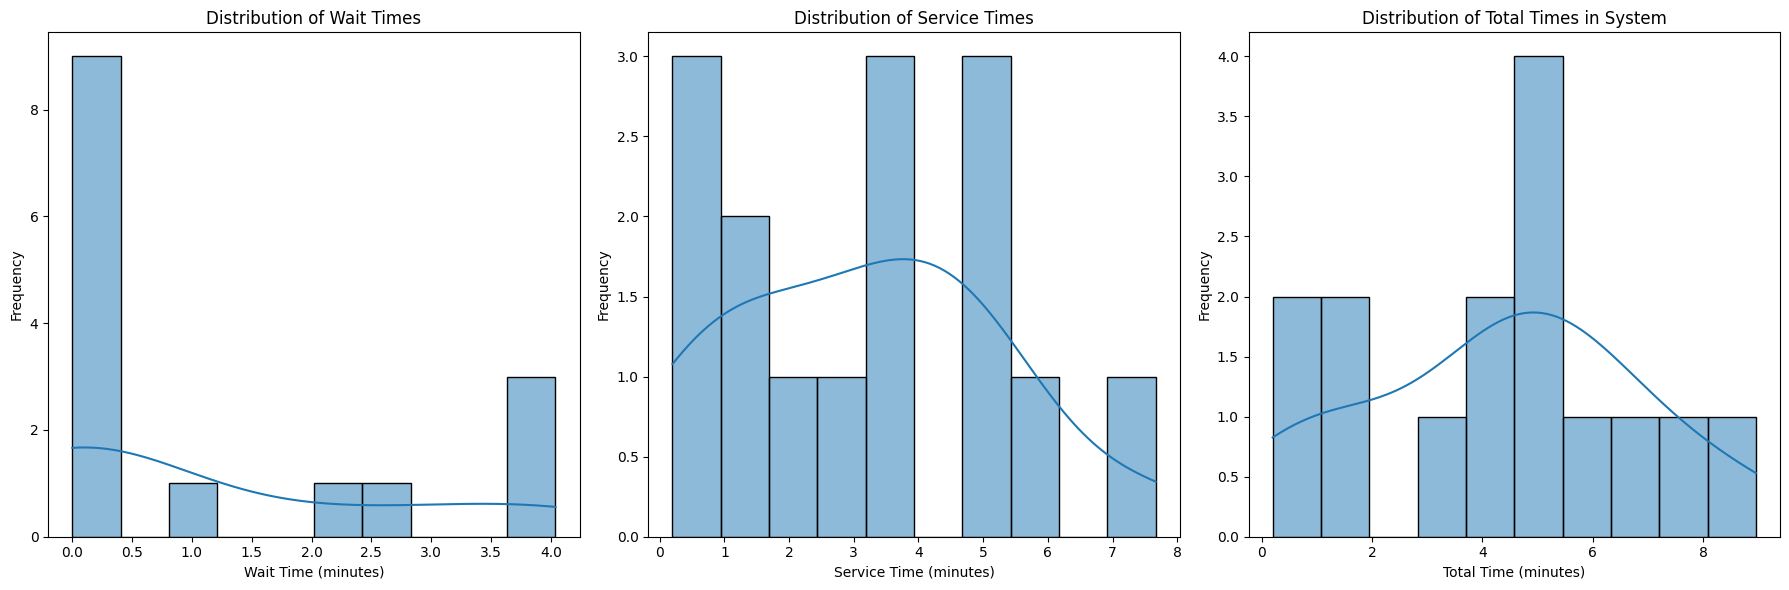

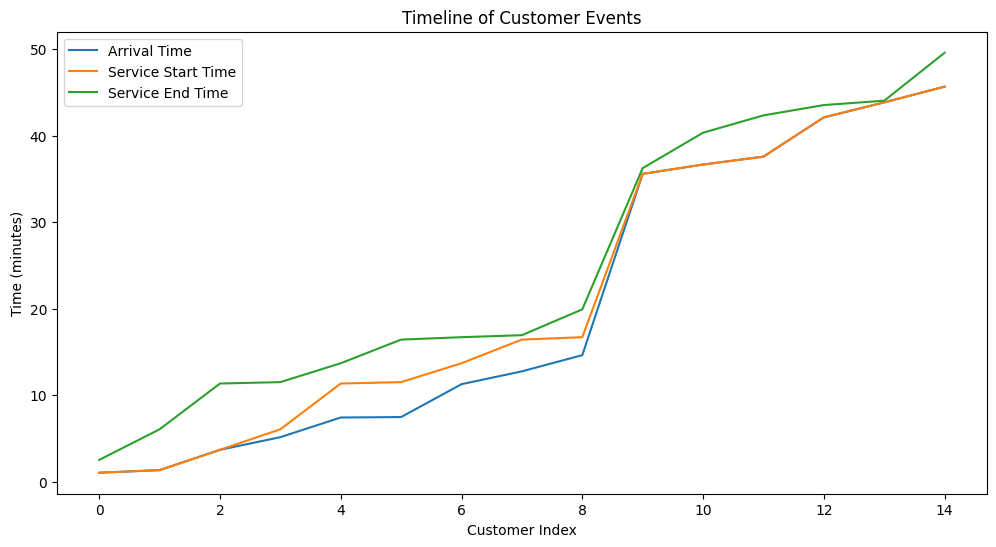

In [5]:
display(Markdown("### Step 3.3: Visualize the Simulation Results"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Plot histograms of wait times, service times, and total times
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
sns.histplot(df['Wait_Time'], kde=True, bins=10)
plt.title('Distribution of Wait Times')
plt.xlabel('Wait Time (minutes)')
plt.ylabel('Frequency')
plt.subplot(1, 3, 2)
sns.histplot(df['Service_Time'], kde=True, bins=10)
plt.title('Distribution of Service Times')
plt.xlabel('Service Time (minutes)')
plt.ylabel('Frequency')
plt.subplot(1, 3, 3)
sns.histplot(df['Total_Time'], kde=True, bins=10)
plt.title('Distribution of Total Times in System')
plt.xlabel('Total Time (minutes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plot the arrival, service start, and service end times
plt.figure(figsize=(12, 6))
plt.plot(df['Arrival_Time'], label='Arrival Time')
plt.plot(df['Service_Start_Time'], label='Service Start Time')
plt.plot(df['Service_End_Time'], label='Service End Time')
plt.title('Timeline of Customer Events')
plt.xlabel('Customer Index')
plt.ylabel('Time (minutes)')
plt.legend()
plt.show()